In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/sensor-data/dataset.csv


#importing required libraries

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns  # visualization tool

In [ ]:
# get dataset from directory
data = pd.read_csv('/dataset.csv')

In [4]:
# shows first 10 row
data.head(10)

,ID,Datetime,Temperature,Humidity,Pressure,Co2 Gas,PM2.5,PM10,Daytime
0,0,"Mon, 20 May 2019 19:08:34 GMT",23.005257,33.060454,972.784433,626,3.8,8.8,Night
1,1,"Mon, 20 May 2019 19:08:35 GMT",22.989942,33.095483,972.844471,627,3.8,8.9,Night
2,2,"Mon, 20 May 2019 19:08:36 GMT",23.000152,33.080467,972.804446,627,3.8,8.9,Night
3,3,"Mon, 20 May 2019 19:08:36 GMT",22.989942,33.105487,972.732905,626,3.8,8.9,Night
4,4,"Mon, 20 May 2019 19:08:37 GMT",22.995047,33.105482,972.768675,626,3.7,8.3,Night
5,5,"Mon, 20 May 2019 19:08:38 GMT",22.995047,33.100480,972.796567,627,3.7,8.3,Night
6,6,"Mon, 20 May 2019 19:08:38 GMT",22.989942,33.125494,972.732905,627,3.7,8.3,Night
7,7,"Mon, 20 May 2019 19:08:39 GMT",22.989942,33.130495,972.816580,626,3.7,8.3,Night
8,8,"Mon, 20 May 2019 19:08:40 GMT",22.995047,33.145496,972.768675,626,3.7,8.2,Night
9,9,"Mon, 20 May 2019 19:08:40 GMT",22.995047,33.145496,972.824459,626,3.7,8.2,Night


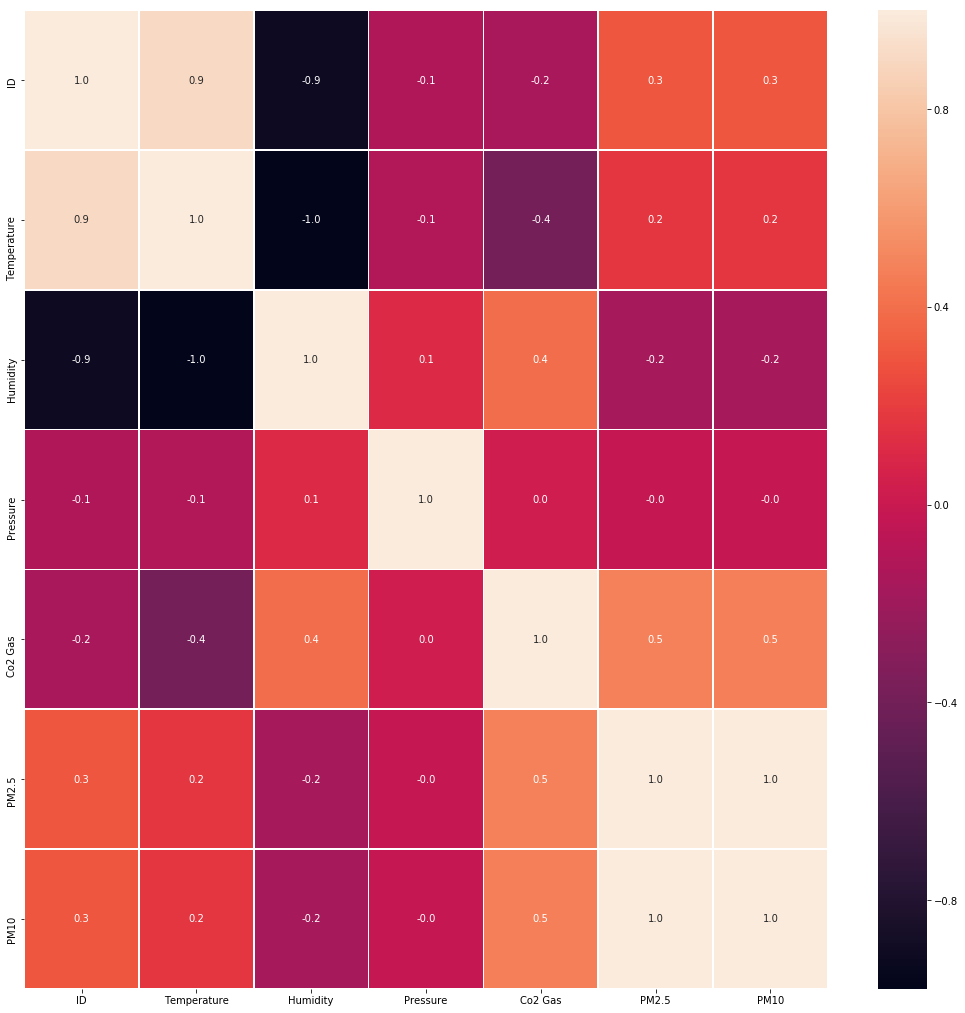

In [5]:

"""
#correlation map  
Determines the relationship between these two variables when an individual has two measurements.
As a result of correlation analysis, whether there is a linear relationship and the degree of this relationship,if any, is calculated with the correlation coefficient.

0.00 No relationship
0.01 – 0.29 low level relationship
0.30 – 0.70 moderate relationshipi
0.71 – 0.99 high level relationship
1.00        perfect relationship
    
annot -> makes text appear
linewidth -> degree of margin
fmt -> determines the number of decimal places to display
ax -> Plot size to be displayed as preset 18x18
    
"""
f,ax = plt.subplots(figsize = (18,18))
sns.heatmap(data.corr(),annot = True , linewidth =.5 , fmt= '.1f' , ax = ax)

Text(0.5, 1.0, 'Temperature-Time Scatter Plot')

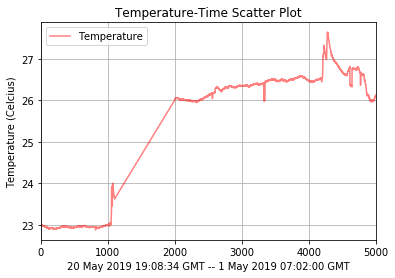

In [6]:
data.plot(kind='line', x ='ID', y='Temperature', alpha = 0.5, grid = True ,color = 'red')
plt.xlabel('20 May 2019 19:08:34 GMT -- 1 May 2019 07:02:00 GMT')
plt.ylabel('Temperature (Celcius)')
plt.title('Temperature-Time Scatter Plot')

As we have seen on the correlation map, PM2.5 and PM10 have a perfect relationship, below we see a scatter plot

Text(0.5, 1.0, 'PM10-PM2.5 Scatter Plot \n 20 May 2019 19:08:34 GMT -- 1 May 2019 07:02:00 GMT')

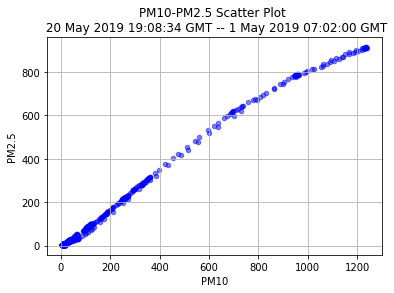

In [7]:
data.plot(kind='scatter', x ='PM10', y='PM2.5', alpha = 0.5, grid = True ,color = 'blue')
plt.xlabel('PM10')
plt.ylabel('PM2.5')
plt.title('PM10-PM2.5 Scatter Plot \n 20 May 2019 19:08:34 GMT -- 1 May 2019 07:02:00 GMT')

In [8]:
# we can also filter the Dataset
filteredData = data[np.logical_and( data['Temperature']> 23, data['Humidity']> 32.5 ) ] 
print(filteredData)

        ID                       Datetime  Temperature   Humidity    Pressure  \
0        0  Mon, 20 May 2019 19:08:34 GMT    23.005257  33.060454  972.784433   
2        2  Mon, 20 May 2019 19:08:36 GMT    23.000152  33.080467  972.804446   
970    970  Mon, 20 May 2019 19:19:16 GMT    23.000152  34.425712  972.804446   
991    991  Mon, 20 May 2019 19:19:30 GMT    23.005257  34.495721  972.840218   
999    999  Mon, 20 May 2019 19:19:35 GMT    23.000152  34.510709  972.776554   
...    ...                            ...          ...        ...         ...   
1095  1095  Mon, 20 May 2019 19:48:52 GMT    23.668909  35.318178  973.222541   
1096  1096  Mon, 20 May 2019 19:49:03 GMT    23.648489  35.393189  973.246874   
1097  1097  Mon, 20 May 2019 19:49:13 GMT    23.643384  35.448231  973.183154   
1098  1098  Mon, 20 May 2019 19:49:24 GMT    23.638279  35.543316  973.286960   
1099  1099  Mon, 20 May 2019 19:49:35 GMT    23.622964  35.708421  973.179565   

      Co2 Gas  PM2.5  PM10 

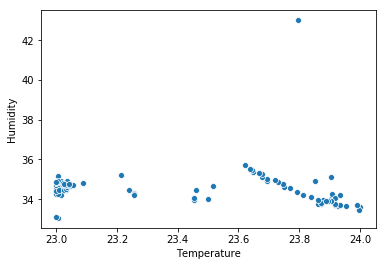

In [9]:
sns.scatterplot(x=filteredData.Temperature,y=filteredData.Humidity,data=data)
